In [36]:
import pandas as pd

init_df = pd.read_csv("DomClick_09.csv")
init_df.head(20)


,Process_ID,Status_Name,DataTime
0,85,ОТПРАВЛЕНО В МИДДЛ,2018-09-20 12:54:00
1,85,ПРОВЕРКА В МИДДЛ,2018-09-20 12:54:00
2,85,ОТПРАВЛЕНО В БАНК,2018-09-20 13:10:00
3,85,ПРИНЯТО В РАБОТУ ЦОПП,2018-09-20 15:30:00
4,85,КРЕДИТНЫЙ АНАЛИЗ,2018-09-20 15:46:00
5,85,КРЕДИТ ОДОБРЕН,2018-09-21 08:29:00
6,1814,ВОЗВРАТ КЛИЕНТУ,2018-09-13 05:27:00
7,1814,ОТПРАВЛЕНО В МИДДЛ,2018-09-13 05:39:00
8,1814,ПРОВЕРКА В МИДДЛ,2018-09-13 05:39:00
9,1814,ОТПРАВЛЕНО В БАНК,2018-09-13 07:55:00


In [37]:
df = init_df.rename(columns={'Process_ID': 'process_id', 'Status_Name': 'status', 'DataTime': 'timestamp'})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['process_id', 'timestamp'])
df.head(20)

,process_id,status,timestamp
0,85,ОТПРАВЛЕНО В МИДДЛ,2018-09-20 12:54:00
1,85,ПРОВЕРКА В МИДДЛ,2018-09-20 12:54:00
2,85,ОТПРАВЛЕНО В БАНК,2018-09-20 13:10:00
3,85,ПРИНЯТО В РАБОТУ ЦОПП,2018-09-20 15:30:00
4,85,КРЕДИТНЫЙ АНАЛИЗ,2018-09-20 15:46:00
5,85,КРЕДИТ ОДОБРЕН,2018-09-21 08:29:00
6,1814,ВОЗВРАТ КЛИЕНТУ,2018-09-13 05:27:00
7,1814,ОТПРАВЛЕНО В МИДДЛ,2018-09-13 05:39:00
8,1814,ПРОВЕРКА В МИДДЛ,2018-09-13 05:39:00
9,1814,ОТПРАВЛЕНО В БАНК,2018-09-13 07:55:00


In [38]:
traces = []
for pid, group in df.groupby('process_id'):
    traces.append(group['status'].tolist()) 

statuses = sorted(set(df['status']))
statuses_set = set(statuses)
T = set(statuses)
print("Statuses list:", statuses)

direct_succession = set()
for trace in traces:
    for i in range(len(trace)-1):
        direct_succession.add((trace[i], trace[i+1]))

Statuses list: ['ВОЗВРАТ КЛИЕНТУ', 'ВОЗВРАТ НА ДОРАБОТКУ', 'КРЕДИТ ОДОБРЕН', 'КРЕДИТНЫЙ АНАЛИЗ', 'Назначена на вторую линию', 'ОТКАЗ БАНКА ПО ЗАЕМЩИКУ', 'ОТКАЗ КЛИЕНТА', 'ОТПРАВЛЕНО В БАНК', 'ОТПРАВЛЕНО В МИДДЛ', 'ПРИНЯТО В РАБОТУ ЦОПП', 'ПРОВЕРКА В МИДДЛ', 'ЧЕРНОВИК']


In [39]:
footprint = {}

for a in statuses:
    for b in statuses:
        if a == b:
            continue
        a_follows_b = (b, a) in direct_succession
        b_follows_a = (a, b) in direct_succession
        if b_follows_a and not a_follows_b:
            footprint[(a,b)] = {'->'}
        elif a_follows_b and not b_follows_a:
            footprint[(b,a)] = {'->'}
        elif b_follows_a and a_follows_b:
            footprint[(a,b)] = {'||'}
            footprint[(b,a)] = {'||'}
        else:
            footprint[(a,b)] = {'#'}
            footprint[(b,a)] = {'#'}

causal = set()
parallel = set()
unrelated = set()

for (a,b), rel in footprint.items():
    if '->' in rel:
        causal.add((a,b))
    elif '||' in rel:
        parallel.add((a,b))
    elif '#' in rel:
        unrelated.add((a,b))

In [40]:
print(f"len(causal): {len(causal)}")
print(f"len(parallel): {len(parallel)}")
print(f"len(unrelated): {len(unrelated)}")

len(causal): 26
len(parallel): 24
len(unrelated): 56


In [41]:
footprint_matrix = pd.DataFrame(index=statuses, columns=statuses, dtype=str)
for a in statuses:
    for b in statuses:
        if a == b:
            footprint_matrix.loc[a,b] = '-'
        elif (a,b) in causal:
            footprint_matrix.loc[a,b] = '→'
            footprint_matrix.loc[b,a] = '←'
        elif (a,b) in parallel: 
            footprint_matrix.loc[a,b] = '||'
        elif (a,b) in unrelated:
            footprint_matrix.loc[a,b] = '#' 
display(footprint_matrix)

,ВОЗВРАТ КЛИЕНТУ,ВОЗВРАТ НА ДОРАБОТКУ,КРЕДИТ ОДОБРЕН,КРЕДИТНЫЙ АНАЛИЗ,Назначена на вторую линию,ОТКАЗ БАНКА ПО ЗАЕМЩИКУ,ОТКАЗ КЛИЕНТА,ОТПРАВЛЕНО В БАНК,ОТПРАВЛЕНО В МИДДЛ,ПРИНЯТО В РАБОТУ ЦОПП,ПРОВЕРКА В МИДДЛ,ЧЕРНОВИК
ВОЗВРАТ КЛИЕНТУ,-,#,→,→,#,→,#,#,||,→,←,→
ВОЗВРАТ НА ДОРАБОТКУ,#,-,→,←,#,#,||,→,#,←,#,→
КРЕДИТ ОДОБРЕН,←,←,-,←,→,#,#,||,→,#,#,||
КРЕДИТНЫЙ АНАЛИЗ,←,→,→,-,#,→,→,→,→,←,#,→
Назначена на вторую линию,#,#,←,#,-,#,#,#,#,#,#,#
ОТКАЗ БАНКА ПО ЗАЕМЩИКУ,←,#,#,←,#,-,#,||,→,←,#,||
ОТКАЗ КЛИЕНТА,#,||,#,←,#,#,-,||,#,←,#,#
ОТПРАВЛЕНО В БАНК,#,←,||,←,#,||,||,-,||,||,←,||
ОТПРАВЛЕНО В МИДДЛ,||,#,←,←,#,←,#,||,-,←,||,←
ПРИНЯТО В РАБОТУ ЦОПП,←,→,#,→,#,→,→,||,→,-,#,||


In [42]:
import itertools

max_set_size = len(statuses)    # может потребоваться ограничить при слишком большом len(statuses)/размере данных; на DomClick_09 отрабатывает относительно быстро

subsets = []
for k in range(1, max_set_size+1):
    for comb in itertools.combinations(statuses, k):
        subsets.append(set(comb))

def all_causal(A, B):
    for a in A:
        for b in B:
            if (a,b) not in causal:
                return False
    return True

def all_unrelated(S):
    for x,y in itertools.combinations(S, 2):
        if (x,y) not in unrelated:
            return False
    return True

def is_maximal(A, B):
    for x in statuses_set - A:
        new_A = A.union({x})
        if all_causal(new_A, B) and all_unrelated(new_A):
            return False
    for y in statuses_set - B:
        new_B = B.union({y})
        if all_causal(A, new_B) and all_unrelated(new_B):
            return False
    return True

places = set()

for A in subsets:
    for B in subsets:
        if not all_causal(A, B):
            continue
        if not all_unrelated(A):
            continue
        if not all_unrelated(B):
            continue
        if is_maximal(A, B):
            places.add((frozenset(A), frozenset(B)))

start_statuses = set(trace[0] for trace in traces)
end_statuses = set(trace[-1] for trace in traces)

start_candidate = (frozenset(), frozenset(start_statuses))
if all_unrelated(start_statuses):
    maximal_start = True
    for y in statuses - start_statuses:
        new_B = start_statuses.union({y})
        if all_unrelated(new_B):
            maximal_start = False
            break
    if maximal_start:
        places.add(start_candidate)

end_candidate = (frozenset(end_statuses), frozenset())
if all_unrelated(end_statuses):
    maximal_end = True
    for x in statuses - end_statuses:
        new_A = end_statuses.union({x})
        if all_unrelated(new_A):
            maximal_end = False
            break
    if maximal_end:
        places.add(end_candidate)

print(f"Number of places: {len(places)}")

Number of places: 22


In [43]:
# !pip install graphviz --break-system-packages

In [44]:
from graphviz import Digraph

def build_petri_net(places, transitions, start_place, end_place):
    dot = Digraph(comment='Petri Net', format='png')
    dot.attr(rankdir='LR')
    
    for t in transitions:
        dot.node(t, t, shape='box', style='filled', fillcolor='lightblue')
    
    place_id = 0
    place_nodes = {}
    for (A, B) in places:
        p_name = f'p{place_id}'
        place_nodes[(A, B)] = p_name
        label = ''
        if A:
            label += 'in: ' + ','.join(sorted(A)) + '\\n'
        if B:
            label += 'out: ' + ','.join(sorted(B))
        if (A, B) == start_place:
            label = 'start\\n' + label
        if (A, B) == end_place:
            label = 'end\\n' + label
        dot.node(p_name, label, shape='circle', style='filled', fillcolor='lightgreen')
        place_id += 1

    for (A, B), p_node in place_nodes.items():
        for t in B:
            dot.edge(p_node, t)
        for t in A:
            dot.edge(t, p_node)
    
    return dot

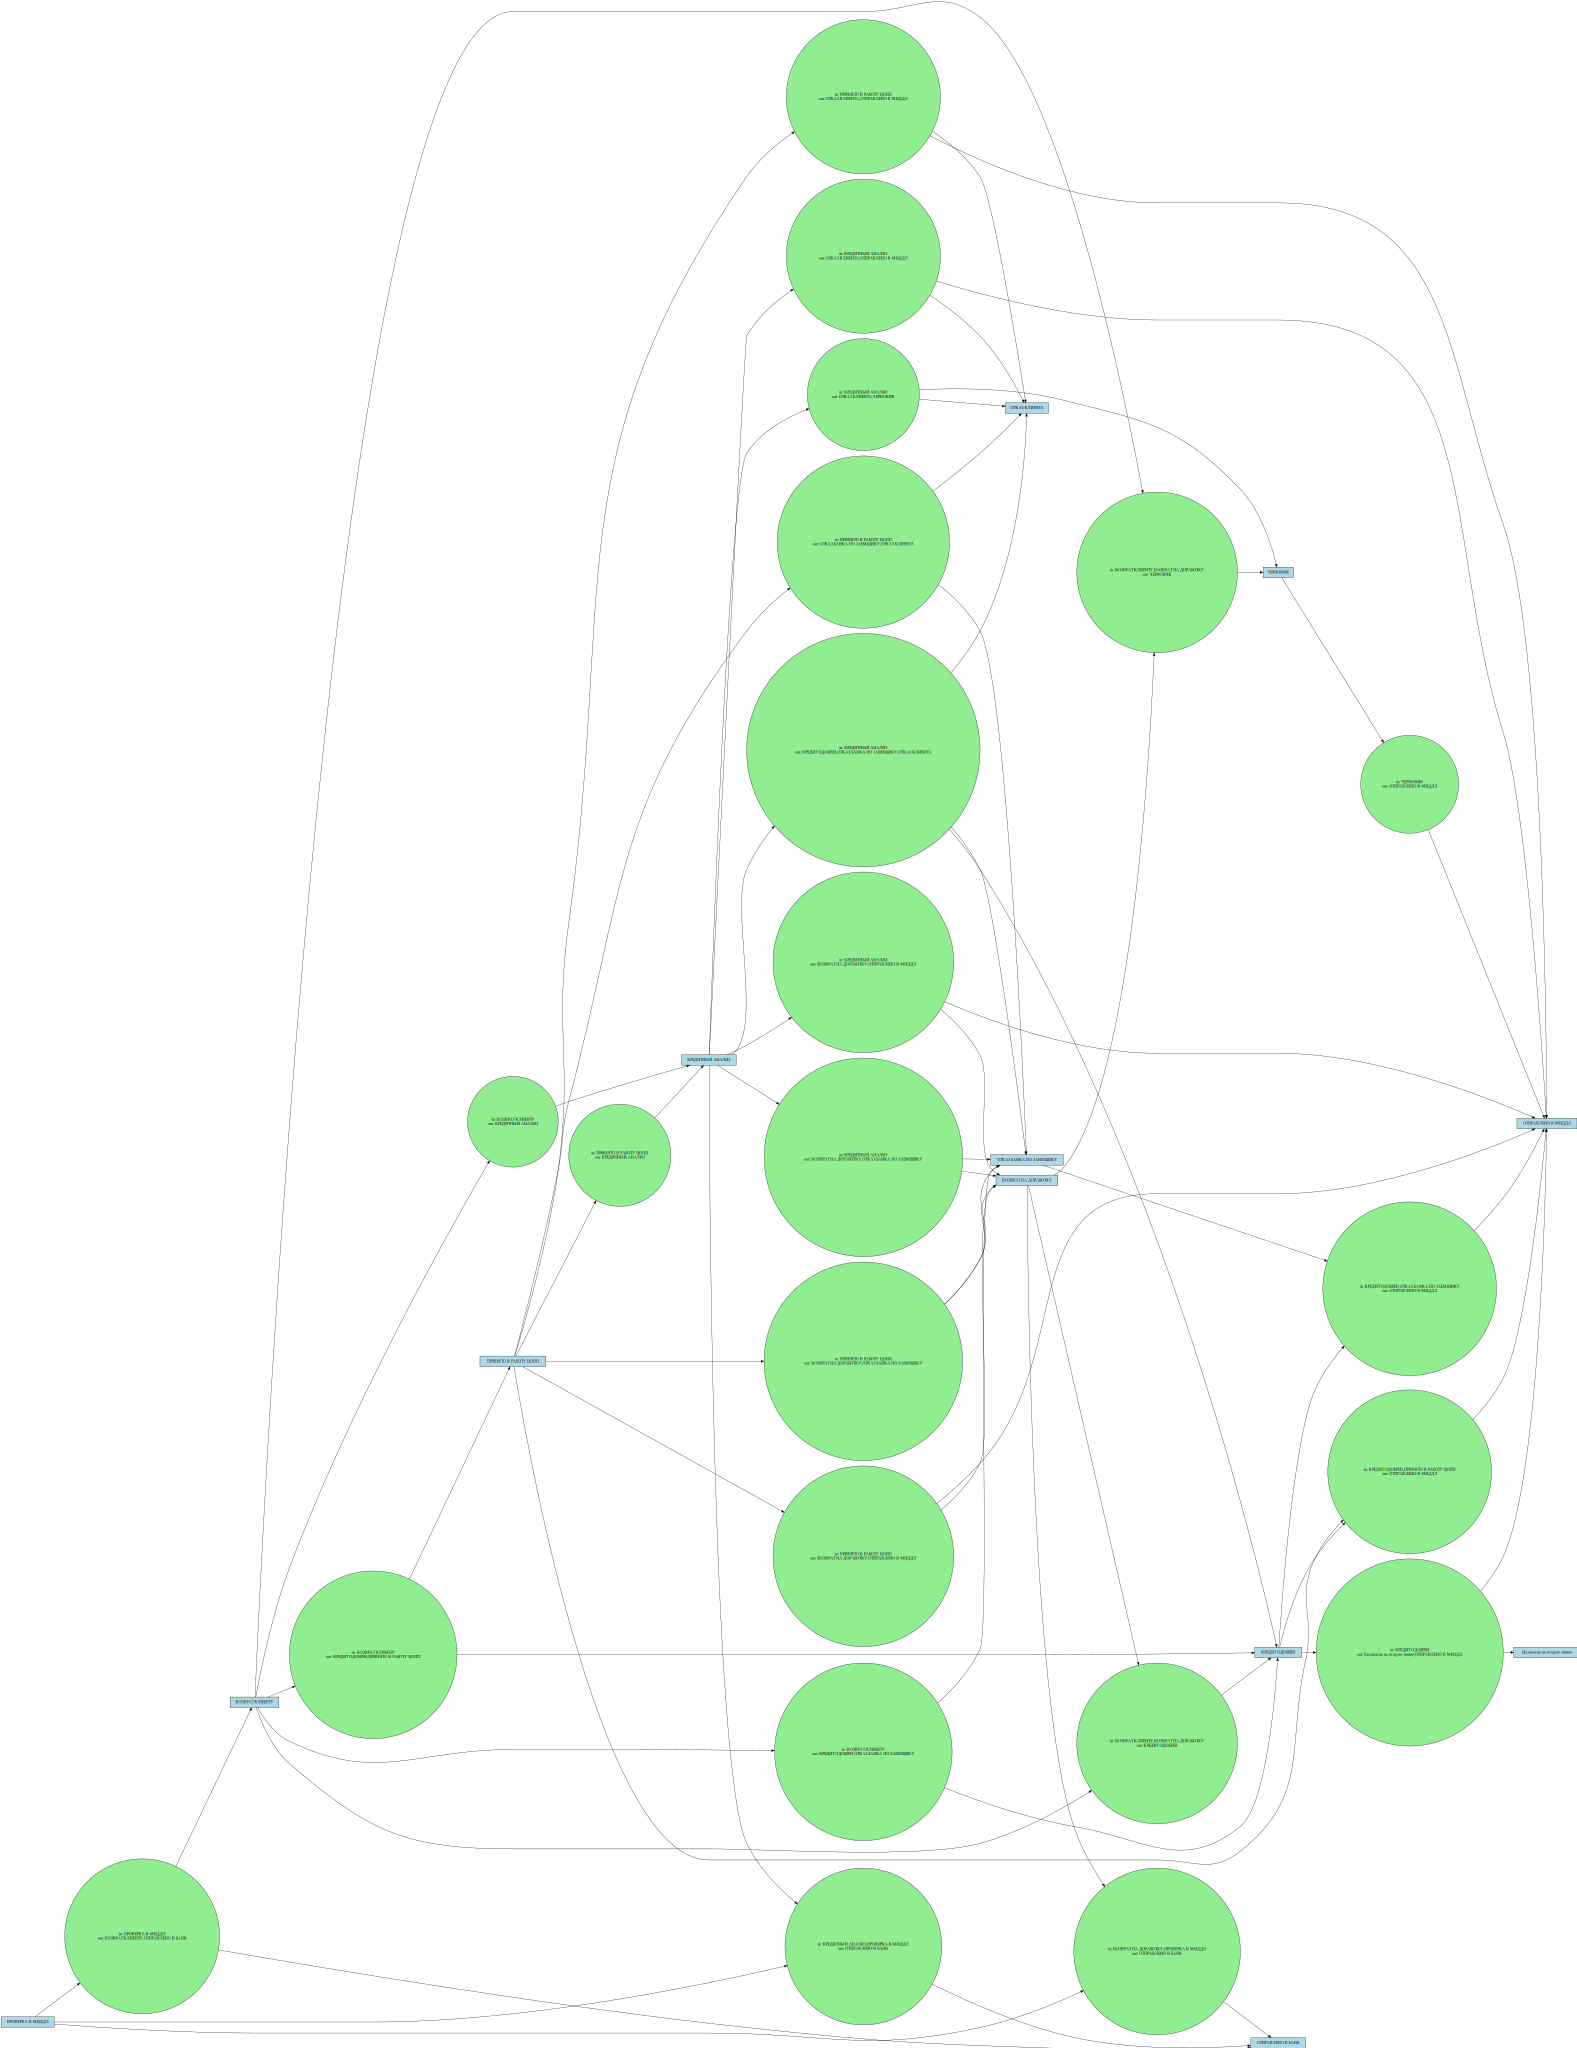

In [45]:
transitions = set(statuses)
dot = build_petri_net(places, transitions, start_candidate, end_candidate)
dot.attr(size='40')

from pathlib import Path
from IPython.display import SVG
output_petri_dot = Path('result_petri_net.dot')
output_petri_svg = Path('result_petri_net.svg')
output_petri_dot.write_text(dot.source)
svg = dot.pipe(format='svg').decode('utf-8')
output_petri_svg.write_text(svg)

SVG(svg)

In [46]:
import numpy as np

n = len(statuses)
idx = {status: i for i, status in enumerate(statuses)}

adj_matrix = np.zeros((n, n), dtype=int)

for pid, group in df.groupby('process_id'):
    trace = group['status'].tolist()
    for i in range(len(trace) - 1):
        a, b = trace[i], trace[i+1]
        adj_matrix[idx[a], idx[b]] += 1

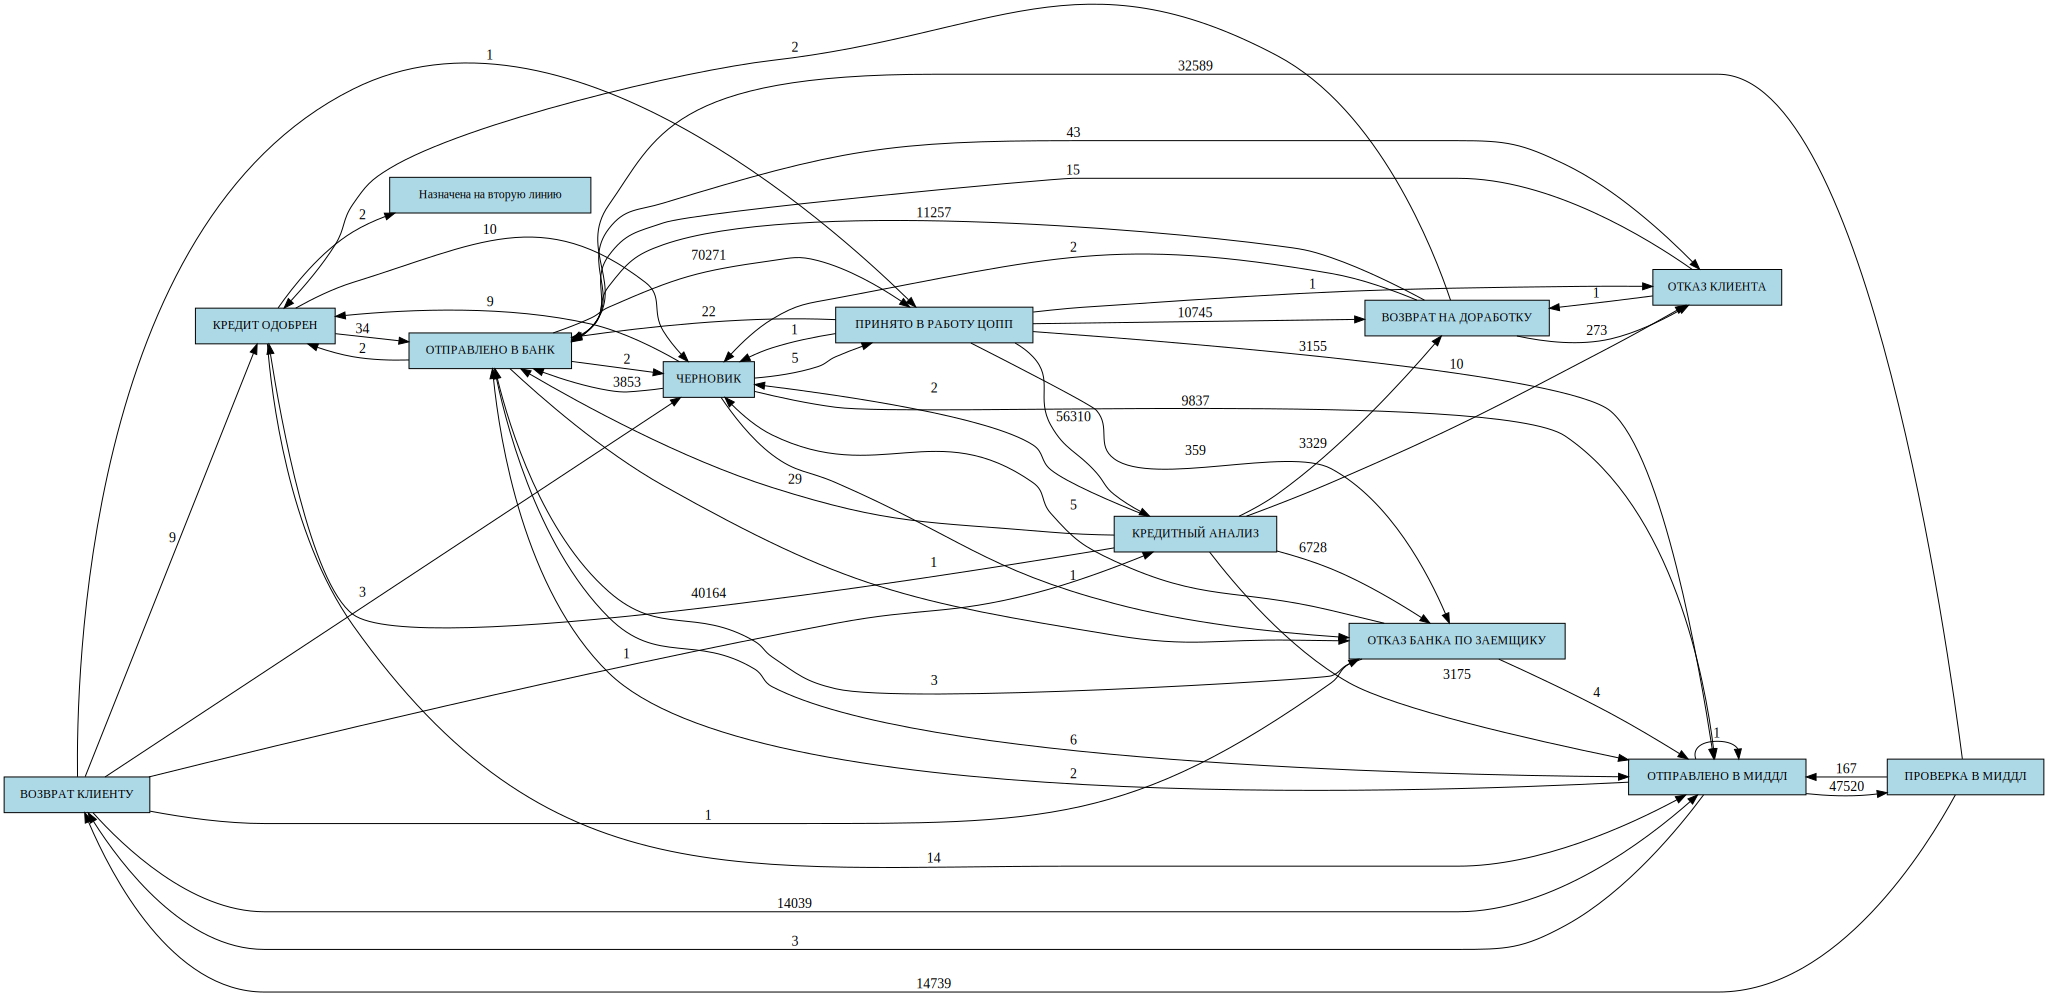

In [47]:
dot = Digraph(comment='Process Graph', format='png')
dot.attr(rankdir='LR', ratio='compress')
dot.attr('node', shape='box', fontsize='12', style='filled', fillcolor='lightblue')
dot.attr('edge', fontsize='14')

for status in statuses:
    dot.node(status, status)

for i, a in enumerate(statuses):
    for j, b in enumerate(statuses):
        weight = adj_matrix[i, j]
        if weight > 0:
            dot.edge(a, b, label=str(weight))  # без penwidth → одинаковая толщина

output_graph_dot = Path('result_recovered_graph.dot')
output_graph_svg = Path('result_recovered_graph.svg')
output_graph_dot.write_text(dot.source)
svg = dot.pipe(format='svg').decode('utf-8')
output_graph_svg.write_text(svg)

SVG(svg)

In [48]:
!pip install networkx --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


## Подсчет метрик

In [49]:
def processes_count(df):
    # Число уникальных процессов
    return df['process_id'].nunique()

def events_count(df):
    # Общее число событий
    return len(df)

def avg_stages_per_process(df):
    # Среднее количество этапов в процессе
    stages_per_process = df.groupby('process_id').size()
    return stages_per_process.mean()

def unique_trace_variants(df):
    # Количество неповторяющихся полных путей-процессов
    traces = df.sort_values(['process_id', 'timestamp']).groupby('process_id')['status'].agg(tuple)
    return traces.nunique()

def avg_process_duration(df):
    # Среднее время обработки одного процесса (в секундах)
    duration = df.groupby('process_id')['timestamp'].agg(lambda x: x.max() - x.min())
    avg_seconds = duration.dt.total_seconds().mean()
    return avg_seconds

def parsing_measure(traces):
    # Доля "хороших" переходов (у которых у целевого статуса мало предшественников или один доминирует).
    from collections import defaultdict, Counter
    
    followers = defaultdict(Counter)
    for trace in traces:
        for i in range(len(trace)-1):
            a, b = trace[i], trace[i+1]
            followers[a][b] += 1
    
    predecessors = defaultdict(set)
    for a, b in direct_succession:
        predecessors[b].add(a)
    
    good = 0
    total = 0
    for a, cnt in followers.items():
        for b, freq in cnt.items():
            total += 1
            if len(predecessors[b]) == 1 or freq > sum(followers[p][b] for p in predecessors[b]) * 0.5:
                good += 1
    return good / total if total > 0 else 1.0

def behavioral_precision_recall(causal, parallel, all_activities):
    # (precision, recall)
    all_pairs = set()
    for a in all_activities:
        for b in all_activities:
            if a != b:
                all_pairs.add((a,b))
    unrelated = all_pairs - causal - parallel
    
    prec = len(causal) / (len(causal) + len(parallel)) if (len(causal) + len(parallel)) > 0 else 1.0
    rec = len(causal) / (len(causal) + len(unrelated)) if (len(causal) + len(unrelated)) > 0 else 1.0
    return prec, rec

def extended_cyclomatic_metric(directly_follows, statuses):
    # Вычисляет E - N + P, где E – число рёбер, N – число узлов (статусов), P – число слабо связных компонент.

    import networkx as nx
    G = nx.DiGraph()
    G.add_nodes_from(statuses)
    G.add_edges_from(directly_follows)
    E = G.number_of_edges()
    N = G.number_of_nodes()
    P = nx.number_weakly_connected_components(G)
    return E - N + P

def advanced_behavioral_appropriateness(directly_follows, statuses):
    # Доля пар статусов, которые НЕ встречаются в логе (чем выше, тем модель специфичнее).
    all_pairs = set()
    for a in statuses:
        for b in statuses:
            if a != b:
                all_pairs.add((a,b))
    missing = all_pairs - directly_follows
    return len(missing) / len(all_pairs) if all_pairs else 1.0

def behavioral_recall_spec_prec(directly_follows, statuses):
    # (recall, specificity, precision) для пар активностей.
    all_pairs = set()
    for a in statuses:
        for b in statuses:
            if a != b:
                all_pairs.add((a,b))
    TP = len(directly_follows)
    FN = 0
    FP = 0
    TN = len(all_pairs - directly_follows)
    
    recall = TP / (TP + FN) if (TP+FN)>0 else 0
    specificity = TN / (TN + FP) if (TN+FP)>0 else 0
    precision = TP / (TP + FP) if (TP+FP)>0 else 0
    return recall, specificity, precision

def extended_cardoso_metric(places):
    # Сумма по каждому месту количества различных переходов, достижимых через 2 шага (место → переход → место → переход).
    ext_card = 0
    # Для каждого места (A, B)
    for A, B in places:
        targets = set()
        # Для каждого выходного перехода b из B
        for b in B:
            # Ищем места, куда ведёт b (т.е. места, у которых b входит во входное множество)
            for next_A, next_B in places:
                if b in next_A:
                    targets.update(next_B)
        ext_card += len(targets)
    return ext_card

print('Processes count:', processes_count(df))
print('Events count:', events_count(df))
print('Average stages per process:', avg_stages_per_process(df))
print('Unique trace variants:', unique_trace_variants(df))
print('Average process duration (seconds):', avg_process_duration(df))
print("Parsing Measure:", parsing_measure(traces))
prec, rec = behavioral_precision_recall(causal, parallel, statuses)
print(f"Behavioral Precision: {prec}, Recall: {rec}")
print("Extended Cyclomatic Metric:", extended_cyclomatic_metric(direct_succession, statuses))
print("Advanced Behavioral Appropriateness:", advanced_behavioral_appropriateness(direct_succession, statuses))
print("Extended Cardoso Metric:", extended_cardoso_metric(places))

Processes count: 56165
Events count: 384922


Average stages per process: 6.853414047894597
Unique trace variants: 1392
Average process duration (seconds): 122071.06881509838
Parsing Measure: 0.19607843137254902
Behavioral Precision: 0.52, Recall: 0.24074074074074073
Extended Cyclomatic Metric: 40
Advanced Behavioral Appropriateness: 0.6212121212121212
Extended Cardoso Metric: 48
